In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from itertools import product

# load the dataset
df = pd.read_csv('C:\Project\Journal\dataset\psa_journal_home_A_synthetic_train.csv')
X = df.drop('Label', axis=1)
y = df['Label']


# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# define the models and hyperparameters
models = {
    'XGBoost': {
        'model': XGBClassifier,
        'params': {
            'learning_rate': [0.01, 0.1],
            'n_estimators': [50, 100]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier,
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    },
    'MLP': {
        'model': MLPClassifier,
        'params': {
            #'hidden_layer_sizes': [(50,), (100,)],
            'hidden_layer_sizes': [(20,), (500,)],
            'activation': ['tanh', 'relu'],
           #'batch_size': [100, 200],
            'batch_size': [50, 100],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN = conf_matrix[0][0]
    FP = conf_matrix[0][1]
    FN = conf_matrix[1][0]
    TP = conf_matrix[1][1]

    TPR = TP / (TP + FN) # true positive rate
    TNR = TN / (TN + FP) # true negative rate
    FPR = FP / (FP + TN) # false positive rate
    FNR = FN / (FN + TP) # false negative rate

    return {'TPR': TPR, 'TNR': TNR, 'FPR': FPR, 'FNR': FNR}

for name, model_info in models.items():
    param_values = [v for v in model_info['params'].values()]
    best_f1 = -1
    best_params = None
    for p in product(*param_values):
        params = dict(zip(model_info['params'].keys(), p))
        if name == 'MLP':
            model = model_info['model'](**params, max_iter=1000)
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model = model_info['model'](**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        f1 = f1_score(y_test, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    models[name]['best_params'] = best_params

    # Compute metrics for each model with best params
    print(f'Metrics for {name} with best params:')
    if name == 'MLP':
        model = model_info['model'](**best_params, max_iter=1000)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model = model_info['model'](**best_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    conf_matrix = confusion_matrix(y_test, preds)
    rates = compute_rates(conf_matrix)
    f1 = f1_score(y_test, preds)
    accuracy = accuracy_score(y_test, preds)
    print(f'Rates: {rates} - F1 Score: {f1} - Accuracy: {accuracy} - Confusion Matrix:\n {conf_matrix}\n')

Metrics for XGBoost with best params:
Rates: {'TPR': 0.9131330977620731, 'TNR': 0.9872492836676218, 'FPR': 0.012750716332378223, 'FNR': 0.08686690223792698} - F1 Score: 0.9481005885500268 - Accuracy: 0.950697066511763 - Confusion Matrix:
 [[6891   89]
 [ 590 6202]]

Metrics for Random Forest with best params:
Rates: {'TPR': 0.8421672555948174, 'TNR': 0.9918338108882522, 'FPR': 0.008166189111747851, 'FNR': 0.15783274440518258} - F1 Score: 0.9101758294215928 - Accuracy: 0.9180220737728725 - Confusion Matrix:
 [[6923   57]
 [1072 5720]]

Metrics for MLP with best params:
Rates: {'TPR': 0.9565665488810365, 'TNR': 0.9868194842406877, 'FPR': 0.013180515759312322, 'FNR': 0.04343345111896349} - F1 Score: 0.9710783947388087 - Accuracy: 0.9718995062445541 - Confusion Matrix:
 [[6888   92]
 [ 295 6497]]



Metrics for XGBoost with best params:
Rates: {'TPR': 0.9131330977620731, 'TNR': 0.9872492836676218, 'FPR': 0.012750716332378223, 'FNR': 0.08686690223792698} - F1 Score: 0.9481005885500268 - Accuracy: 0.950697066511763 - Confusion Matrix:
 [[6891   89]
 [ 590 6202]]

ROC Score: 0.9875801655242474


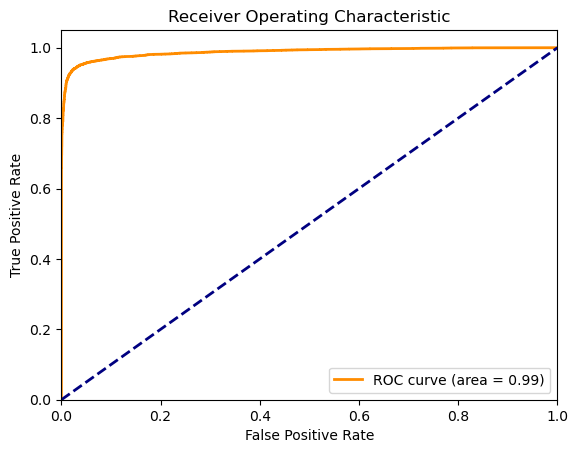

Metrics for Random Forest with best params:
Rates: {'TPR': 0.8429034157832744, 'TNR': 0.9918338108882522, 'FPR': 0.008166189111747851, 'FNR': 0.15709658421672557} - F1 Score: 0.9106091935740417 - Accuracy: 0.9183851292477491 - Confusion Matrix:
 [[6923   57]
 [1067 5725]]

ROC Score: 0.965387994387464


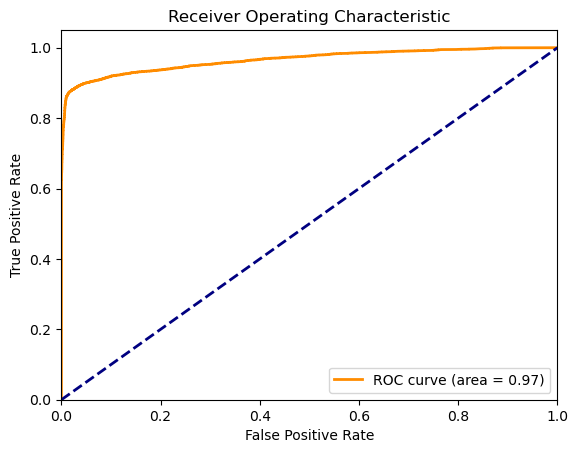

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:699: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from itertools import product

# ... (rest of your code)
# load the dataset
df = pd.read_csv('C:\Project\Journal\dataset\psa_journal_home_A_synthetic_train.csv')
X = df.drop('Label', axis=1)
y = df['Label']


# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# define the models and hyperparameters
models = {
    'XGBoost': {
        'model': XGBClassifier,
        'params': {
            'learning_rate': [0.01, 0.1],
            'n_estimators': [50, 100]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier,
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    },
    'MLP': {
        'model': MLPClassifier,
        'params': {
            #'hidden_layer_sizes': [(50,), (100,)],
            'hidden_layer_sizes': [(20,), (500,)],
            'activation': ['tanh', 'relu'],
           #'batch_size': [100, 200],
            'batch_size': [50, 100],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN = conf_matrix[0][0]
    FP = conf_matrix[0][1]
    FN = conf_matrix[1][0]
    TP = conf_matrix[1][1]

    TPR = TP / (TP + FN) # true positive rate
    TNR = TN / (TN + FP) # true negative rate
    FPR = FP / (FP + TN) # false positive rate
    FNR = FN / (FN + TP) # false negative rate

    return {'TPR': TPR, 'TNR': TNR, 'FPR': FPR, 'FNR': FNR}

for name, model_info in models.items():
    param_values = [v for v in model_info['params'].values()]
    best_f1 = -1
    best_params = None
    for p in product(*param_values):
        params = dict(zip(model_info['params'].keys(), p))
        if name == 'MLP':
            # ... (rest of your code for model training)
            model = model_info['model'](**params, max_iter=1000)
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            # ... (rest of your code for model training)
            model = model_info['model'](**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        f1 = f1_score(y_test, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    models[name]['best_params'] = best_params

    # Compute metrics for each model with best params
    print(f'Metrics for {name} with best params:')
    if name == 'MLP':
        # ... (rest of your code for model training)
        model = model_info['model'](**best_params, max_iter=1000)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        # ... (rest of your code for model training)
        model = model_info['model'](**best_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    conf_matrix = confusion_matrix(y_test, preds)
    rates = compute_rates(conf_matrix)
    f1 = f1_score(y_test, preds)
    accuracy = accuracy_score(y_test, preds)

    # Compute ROC and AUC
    roc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    print(f'Rates: {rates} - F1 Score: {f1} - Accuracy: {accuracy} - Confusion Matrix:\n {conf_matrix}\n')
    print(f'ROC Score: {roc_score}')

    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_score)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
